# Eureka-Audio pt-PT — Replicação (Etapa 2)

Avaliação de ASR do modelo **`cslys1999/Eureka-Audio-Instruct`** no dataset
**MInDS-14, segmento pt-PT** (`PolyAI/minds14`), replicando o protocolo de
avaliação do artigo original (arXiv:2602.13954) em português europeu.

## Ambiente

- **GPU recomendada: L4 ou A100** (Ampere+). Na T4 (Turing) o flash-attn,
  exigido pelo código oficial do modelo, não tem suporte adequado e a
  instalação por compilação é inviável em tempo hábil (problema amplamente
  documentado; ver seção de Ambiente de Execução no artigo). Usamos SDPA
  (Scaled Dot Product Attention, nativo do PyTorch) como substituto
  numericamente equivalente, via patches aplicados na célula de carregamento
  do modelo.
- Se só tiver acesso a T4, a célula de fallback com quantização 4-bit está
  disponível, mas introduz uma variável confundidora frente à precisão
  original do artigo: considere como limitação da replicação, não como equivalente.

## Desenho experimental: dois cenários de prompt

- **Cenário A**: prompt original do artigo (fiel à replicação)
- **Cenário B**: prompt com reforço explícito de idioma (mitigação
  testada após observação, em fase piloto, de que o modelo por vezes
  produzia saída em outro idioma em vez de transcrever em português)

Os dois são comparados nas mesmas amostras (teste pareado de Wilcoxon).

## Armazenamento de resultados

Os resultados são salvos no Google Drive de quem executar o notebook
(`drive.mount()` monta a conta de quem estiver rodando, não a de quem criou
o notebook), isso garante que o progresso sobrevive a quedas de conexão do
Colab, e que qualquer pessoa reproduzindo o experimento tem sua própria cópia
isolada dos resultados, sem conflito com a execução original.

## Autenticação HuggingFace

Necessária para evitar rate-limit em downloads anônimos (causa de erros de
arquivo incompleto observados durante o desenvolvimento). Configure um
`HF_TOKEN` em **Colab -> Secrets** antes de rodar, ou use o login
interativo quando solicitado pela célula correspondente.

## Passo a passo

**Runtime -> Alterar tipo de ambiente de execução -> GPU -> L4** (ou A100, se
disponível), depois execute as células em ordem.

In [1]:
# 1. Instalar dependências do NOSSO pipeline
!pip install -q datasets soundfile jiwer scipy pandas matplotlib numpy tqdm huggingface_hub


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 69.1 MB/s eta 0:00:00


## 2. Conectar e salvar arquivos

Detecta o ambiente no qual o notebook está sendo executado, seja Jupter local, VS Code, Colab, etc.

In [ ]:
# Detecta automaticamente se está rodando no Google Colab ou em outro ambiente
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

import os

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT_DIR = '/content/drive/MyDrive/eureka-audio-pt-replication'
else:
    # Fora do Colab: salva localmente, na pasta onde o notebook está rodando.
    PROJECT_DIR = os.path.join(os.getcwd(), 'eureka-audio-pt-replication')

os.makedirs(f'{PROJECT_DIR}/results/plots', exist_ok=True)
print(f"Ambiente detectado: {'Google Colab' if IN_COLAB else 'outro (local/VS Code/Kaggle/etc.)'}")
print(f"Resultados serão salvos em: {PROJECT_DIR}")

Mounted at /content/drive
Resultados serão salvos em: /content/drive/MyDrive/eureka-audio-pt-replication


## 3. Autenticação no HuggingFace

Recomendado: salve seu token do Huggin Face em **Colab -> Secrets -> adicionar `HF_TOKEN`**
(ícone de chave na barra lateral esquerda), depois rode a célula abaixo. Se
preferir, use `huggingface_hub.login()` para inserir o token interativamente
(sem salvar nos secrets).

In [ ]:
from huggingface_hub import login

hf_token = None
if IN_COLAB:
    try:
        from google.colab import userdata
        hf_token = userdata.get('HF_TOKEN')
    except Exception:
        pass
else:
    hf_token = os.environ.get('HF_TOKEN')  # `export HF_TOKEN=...`

if hf_token:
    login(token=hf_token)
    print("Login feito com token encontrado automaticamente.")
else:
    print("HF_TOKEN não encontrado automaticamente, informe manualmente:")
    login()  # funciona em Colab, Jupyter local e terminal

Login feito com token salvo nos Secrets do Colab.


## 4. Clonar o repositório oficial do modelo (código de inferência)

`flash-attn` é removido do `requirements.txt` antes da instalação. A
compilação dessa dependência a partir do código-fonte é um problema
amplamente documentado, com relatos de instalação levando de 1 a várias horas,
inclusive em GPUs Ampere/Ada no Google Colab, aparecendo tanto nas issues
oficiais do repositório quanto em relatos independentes de desenvolvedores.
Como alternativa, forçamos a implementação de atenção `sdpa` (Scaled Dot
Product Attention, nativa do PyTorch) na célula de carregamento do modelo,
equivalente numericamente ao FlashAttention-2, diferindo apenas na engenharia
de kernels CUDA.


In [4]:
!git clone https://github.com/Alittleegg/Eureka-Audio.git eureka_audio_lib
!sed -i '/flash-attn/d' eureka_audio_lib/requirements.txt
%cd eureka_audio_lib
!pip install -q -r requirements.txt
%cd ..

Cloning into 'eureka_audio_lib'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 53 (delta 17), reused 39 (delta 8), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 3.77 MiB | 19.60 MiB/s, done.
Resolving deltas: 100% (17/17), done.
/content/eureka_audio_lib
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.7 MB/s eta 0:00:00
/content


## 5. Imports e checagem do ambiente

In [5]:
import sys, json, os, random, tempfile, time, traceback
from pathlib import Path

import numpy as np
import torch
import torchaudio
import soundfile as sf
import jiwer
from datasets import load_dataset
from tqdm.notebook import tqdm

sys.path.insert(0, './eureka_audio_lib')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("CUDA disponível:", torch.cuda.is_available())
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    major, minor = torch.cuda.get_device_capability(0)
    print(f"GPU: {gpu_name} (compute capability {major}.{minor})")
    is_ampere_plus = major >= 8
    print("Suporta flash-attn 2 nativamente:" , is_ampere_plus)
    torch.cuda.reset_peak_memory_stats()
else:
    is_ampere_plus = False


CUDA disponível: True
GPU: NVIDIA L4 (compute capability 8.9)
Suporta flash-attn 2 nativamente: True


## 6. Baixar o modelo

Baixar com `snapshot_download` para um diretório local evita o problema de
symlinks quebrados do cache padrão do HuggingFace.


In [6]:
from huggingface_hub import snapshot_download

MODEL_PATH = "cslys1999/Eureka-Audio-Instruct"
LOCAL_MODEL_DIR = "./eureka_model_weights"

print("Baixando modelo do HuggingFace (pode levar alguns minutos)...")
snapshot_download(repo_id=MODEL_PATH, local_dir=LOCAL_MODEL_DIR)
print(f"Download concluído em: {LOCAL_MODEL_DIR}")
print("Arquivos baixados:", os.listdir(LOCAL_MODEL_DIR))


Baixando modelo do HuggingFace (pode levar alguns minutos)...


Fetching 24 files:   0%|          | 0/24 [00:00<?, ?it/s]

Download concluído em: ./eureka_model_weights
Arquivos baixados: ['merges.txt', 'model.safetensors.index.json', 'tokenizer_config.json', 'model-00001-of-00002.safetensors', 'generation_config.json', 'config.json', 'modeling_eureka_audio.py', 'added_tokens.json', 'mel_filters.npz', '.cache', 'vocab.json', 'chat_template.json', 'configuration.json', 'assets', '.gitattributes', 'README.md', 'model-00002-of-00002.safetensors', 'special_tokens_map.json', 'tokenizer.json', 'configuration_eureka_audio.py', 'preprocessor_config.json']


## 6A. Checagem de arquivos locais

**Checagem rápida dos arquivos locais baixados do Huggin Face**


In [7]:
import os

print("Conteúdo de LOCAL_MODEL_DIR:")
for f in sorted(os.listdir(LOCAL_MODEL_DIR)):
    print(" -", f)

print()
for fname in ["modeling_eureka_audio.py", "configuration_eureka_audio.py"]:
    p = os.path.join(LOCAL_MODEL_DIR, fname)
    exists = os.path.exists(p)
    is_link = os.path.islink(p)
    print(f"{fname}: existe={exists}, é symlink={is_link}", end="")
    if is_link:
        target = os.readlink(p)
        print(f", aponta para={target}, alvo existe={os.path.exists(os.path.realpath(p))}")
    else:
        print()
    if exists and not is_link:
        print(f"  tamanho: {os.path.getsize(p)} bytes")

Conteúdo de LOCAL_MODEL_DIR:
 - .cache
 - .gitattributes
 - README.md
 - added_tokens.json
 - assets
 - chat_template.json
 - config.json
 - configuration.json
 - configuration_eureka_audio.py
 - generation_config.json
 - mel_filters.npz
 - merges.txt
 - model-00001-of-00002.safetensors
 - model-00002-of-00002.safetensors
 - model.safetensors.index.json
 - modeling_eureka_audio.py
 - preprocessor_config.json
 - special_tokens_map.json
 - tokenizer.json
 - tokenizer_config.json
 - vocab.json

modeling_eureka_audio.py: existe=True, é symlink=False
  tamanho: 18842 bytes
configuration_eureka_audio.py: existe=True, é symlink=False
  tamanho: 5617 bytes


## 6B. Patching Eureka Audio (Solução para Erros de Flash Attention e Dependências)

Esta célula aplica uma série de patches para garantir que o modelo Eureka Audio possa ser carregado e executado corretamente, especialmente em ambientes onde o `flash-attn` não está disponível ou onde há problemas com a detecção de `tied_weights` no `transformers`.

### O que é feito:
1.  **Definição de Caminhos Absolutos**: Garante que o diretório do modelo (`LOCAL_MODEL_DIR`) esteja no `sys.path` para que os módulos possam ser importados.
2.  **Patches Globais**: Modifica o comportamento padrão do `transformers` para forçar o uso da implementação de atenção `sdpa` (Scaled Dot Product Attention), que é mais compatível com uma gama maior de GPUs e evita a dependência de `flash-attn`. Também desabilita a detecção de `flash_attn_2` e reseta `all_tied_weights_keys`.
3.  **Importação Dinâmica**: Importa `modeling_eureka_audio` e recarrega para garantir que os patches sejam aplicados corretamente. A classe `EurekaAudioForCausalLM` é então usada para carregar o modelo.
4.  **Carregamento dos Pesos**: O modelo (`raw_model`) é carregado do `abs_model_path` com `torch.bfloat16` para maior precisão e `device_map="auto"` para distribuir o modelo pela GPU.
5.  **Patch na Classe `EurekaAudio` (API)**: A classe `EurekaAudio` da API é modificada para usar o modelo `raw_model` carregado e para garantir que o processador (`AutoProcessor`) esteja configurado corretamente.
6.  **Extração Robusta de Tokens e Vocab**: Garante que os IDs de token essenciais (`audio_start_id`, `audio_end_id`, `audio_placeholder_id`) e o `vocab_size` sejam corretamente extraídos da configuração do modelo e injetados na API, com fallbacks manuais caso não sejam encontrados automaticamente.

In [15]:
import sys
import torch
import os
import importlib.util
import transformers
from transformers import AutoModelForCausalLM, PretrainedConfig, PreTrainedModel, AutoProcessor
from eureka_infer.api import EurekaAudio

# 1. Definicao de caminhos absolutos (como pacote Python de verdade)
abs_model_path = os.path.abspath(LOCAL_MODEL_DIR)

for mod_name in list(sys.modules):
    if mod_name.startswith("modeling_eureka_audio") or mod_name.startswith("configuration_eureka_audio"):
        del sys.modules[mod_name]
if abs_model_path in sys.path:
    sys.path.remove(abs_model_path)

init_path = os.path.join(abs_model_path, "__init__.py")
if not os.path.exists(init_path):
    open(init_path, "w").close()

parent_dir = os.path.dirname(abs_model_path)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

package_name = os.path.basename(abs_model_path)

# 2. Patches globais
PreTrainedModel.get_correct_attn_implementation = classmethod(lambda cls, *args, **kwargs: "sdpa")
transformers.modeling_utils.PreTrainedModel.get_correct_attn_implementation = classmethod(lambda cls, *args, **kwargs: "sdpa")
PretrainedConfig.get_infer_attn_implementation = lambda self: "sdpa"
transformers.utils.import_utils.is_flash_attn_2_available = lambda: False
transformers.modeling_utils.is_flash_attn_2_available = lambda *args, **kwargs: False
PreTrainedModel.all_tied_weights_keys = {}

try:
    # 3. Importacao dinâmica (via pacote)
    modeling_eureka_audio = importlib.import_module(f"{package_name}.modeling_eureka_audio")
    EurekaClass = modeling_eureka_audio.EurekaAudioForCausalLM
    EurekaClass.all_tied_weights_keys = {}

    if 'raw_model' in locals():
        del raw_model
    torch.cuda.empty_cache()

    # 4. Carregamento dos pesos
    print("Carregando pesos do modelo na memoria...")
    raw_model = EurekaClass.from_pretrained(
        abs_model_path,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        trust_remote_code=True
    )

    # 5. Patch na classe EurekaAudio (API)
    def patched_init(self, model_path, **kwargs):
        self.model_path = model_path
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.mel_filter_path = os.path.join(model_path, "mel_filters.npz")
        print("API EurekaAudio inicializada.")

    EurekaAudio.__init__ = patched_init
    model = EurekaAudio(model_path=abs_model_path)
    model.model = raw_model

    processor = AutoProcessor.from_pretrained(abs_model_path, trust_remote_code=True)
    model.processor = processor

    # EXTRAÇÃO ROBUSTA DE TOKENS E VOCAB
    def get_token_id(cfg, key):
        if hasattr(cfg, key) and getattr(cfg, key) is not None:
            return getattr(cfg, key)
        a_cfg = getattr(cfg, 'audio_config', {})
        if isinstance(a_cfg, dict):
            return a_cfg.get(key)
        return getattr(a_cfg, key, None)

    s_id = get_token_id(raw_model.config, 'audio_start_id')
    e_id = get_token_id(raw_model.config, 'audio_end_id')
    p_id = get_token_id(raw_model.config, 'audio_placeholder_id')

    # Fallbacks manuais
    if s_id is None: s_id = 151646
    if e_id is None: e_id = 151647
    if p_id is None: p_id = 151648

    # Injetando vocab_size para a API (exigido por eureka_infer/api/eureka.py)
    v_size = getattr(raw_model.config, 'vocab_size', 151936)

    # Injetando em todos os lugares necessarios
    for obj in [raw_model.config, model]:
        obj.audio_start_id = s_id
        obj.audio_end_id = e_id
        obj.audio_placeholder_id = p_id
        obj.vocab_size = v_size

    if hasattr(processor, "tokenizer"):
        model.tokenizer = processor.tokenizer
    else:
        from transformers import AutoTokenizer
        model.tokenizer = AutoTokenizer.from_pretrained(abs_model_path, trust_remote_code=True)

    print(f"API pronta. IDs: Start={s_id}, End={e_id}, Placeholder={p_id}, Vocab={v_size}")
    print(f"VRAM alocada: {torch.cuda.memory_allocated()/1024**2:.2f} MB")

except Exception as e:
    print(f"Erro durante o carregamento: {e}")
    import traceback
    traceback.print_exc()

QUANTIZED = False

Carregando pesos do modelo na memoria...


Loading weights:   0%|          | 0/853 [00:00<?, ?it/s]

[transformers] EurekaAudioForCausalLM LOAD REPORT from: /content/eureka_model_weights
Key                                   | Status     |  | 
--------------------------------------+------------+--+-
audio_ffn_adaptor.{0, 1, 3, 4}.weight | UNEXPECTED |  | 
audio_ffn_adaptor.{0, 1, 3, 4}.bias   | UNEXPECTED |  | 
audio_out_projection.{0, 1, 3}.weight | UNEXPECTED |  | 
audio_head.weight                     | UNEXPECTED |  | 
lm_head.weight                        | UNEXPECTED |  | 
audio_embed.weight                    | UNEXPECTED |  | 
audio_out_projection.{0, 1, 3}.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


API EurekaAudio inicializada.
API pronta. IDs: Start=151646, End=151647, Placeholder=151648, Vocab=151936
VRAM alocada: 5250.40 MB


## 6-fallback. Quantização 4-bit: fallback para GPUs com pouca VRAM (T4)

Só executa se a célula anterior não conseguir carregar o modelo
(`if 'model' not in locals()`). Introduz quantização NF4, uma variável
confundidora frente à precisão `float16` do artigo original. **Na execução final em L4, esta célula não foi acionada** (`QUANTIZED = False`); o modelo rodou em precisão cheia.


In [ ]:
# Celula de Fallback: Carregamento em 4-bit para GPUs com menos VRAM (ex: T4)
if 'model' not in locals():
    print("Modelo nao detectado. Iniciando carregamento com quantizacao 4-bit para compatibilidade...")

    # Instalacao de dependencias especificas para quantizacao
    !pip install -q bitsandbytes accelerate

    import torch
    from transformers import BitsAndBytesConfig, AutoProcessor
    from eureka_infer.api import EurekaAudio
    import modeling_eureka_audio

    # Configuracao de quantizacao NF4
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_use_double_quant=True,
    )

    abs_model_path = os.path.abspath(LOCAL_MODEL_DIR)

    # Aplicacao dos patches de tied_weights para a classe de quantizacao
    modeling_eureka_audio.EurekaAudioForCausalLM.all_tied_weights_keys = {}

    # Carregamento do modelo quantizado
    raw_model = modeling_eureka_audio.EurekaAudioForCausalLM.from_pretrained(
        abs_model_path,
        quantization_config=bnb_config,
        device_map="auto",
        trust_remote_code=True
    )

    # Interceptacao da API para usar o modelo quantizado
    def patched_init(self, model_path, **kwargs):
        self.model_path = model_path
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    EurekaAudio.__init__ = patched_init
    model = EurekaAudio(model_path=abs_model_path)
    model.model = raw_model
    model.processor = AutoProcessor.from_pretrained(abs_model_path, trust_remote_code=True)

    QUANTIZED = True
    print(f"Modelo carregado em 4-bit. VRAM alocada: {torch.cuda.memory_allocated()/1024**2:.2f} MB")
else:
    print("Modelo ja carregado em precisao total (L4/A100). Ignorando fallback de quantizacao.")
    QUANTIZED = False

## 7. Funções auxiliares — dois prompts (cenário A e B)

- **Cenário A**: prompt original do artigo (fiel à replicação)
- **Cenário B**: prompt com reforço de idioma (mitigação testada)


In [16]:
PROMPT_A_ORIGINAL = "You are an advanced ASR (Automatic Speech Recognition) AI assistant."
PROMPT_B_PT_PINNED = (
    "You are an advanced ASR assistant. You MUST transcribe the audio exactly "
    "as spoken in Portuguese. Do NOT translate. Output ONLY the Portuguese transcription."
)

text_transform = jiwer.Compose([
    jiwer.ToLowerCase(),
    jiwer.RemovePunctuation(),
    jiwer.RemoveMultipleSpaces(),
    jiwer.Strip(),
])

def build_messages(wav_path, system_prompt):
    return [
        {"role": "system", "content": [{"type": "text", "text": system_prompt}]},
        {"role": "user", "content": [{"type": "audio_url", "audio_url": {"url": wav_path}}]},
    ]

def audio_dict_to_wav(audio_dict, target_sr=16000):
    array = audio_dict["array"]
    sr = audio_dict["sampling_rate"]
    if sr != target_sr:
        waveform = torch.tensor(array, dtype=torch.float32).unsqueeze(0)
        waveform = torchaudio.functional.resample(waveform, sr, target_sr)
        array = waveform.squeeze(0).numpy()
    else:
        array = np.asarray(array, dtype=np.float32)
    tmp = tempfile.NamedTemporaryFile(suffix=".wav", delete=False)
    sf.write(tmp.name, array, target_sr)
    return tmp.name

def transcribe_one(audio_dict, system_prompt, max_new_tokens=256, latency_repeats=3):
    wav_path = audio_dict_to_wav(audio_dict)
    messages = build_messages(wav_path, system_prompt)
    latencies = []
    hypothesis = None
    for _ in range(latency_repeats):
        t0 = time.perf_counter()
        response = model.generate(
            messages, temperature=0.0, top_p=0.0, top_k=0,
            do_sample=False, max_new_tokens=max_new_tokens,
        )
        t1 = time.perf_counter()
        latencies.append(t1 - t0)
        if hypothesis is None:
            hypothesis = response
    os.unlink(wav_path)
    return hypothesis, latencies


## 8. Teste com uma amostra, os dois prompts

Compara visualmente as saídas do Cenário A e B na mesma amostra.

In [22]:
dataset_probe = load_dataset("PolyAI/minds14", "pt-PT", split="train")

print(f"Amostras disponíveis: {len(dataset_probe)}")
sample = dataset_probe[0]
print("Referência:", sample["transcription"])

for label, prompt in [("A (original)", PROMPT_A_ORIGINAL), ("B (pin de idioma)", PROMPT_B_PT_PINNED)]:
    hyp, lat = transcribe_one(sample["audio"], prompt, latency_repeats=1)
    print(f"\n--- Cenário {label} ---")
    print("Hipótese:", hyp)
    print(f"Latência: {lat[0]:.2f}s")


Amostras disponíveis: 604
Referência: Bom dia estou a ligar porque precisava de informações sobre como é que eu posso depositar dinheiro na minha conta

--- Cenário A (original) ---
Hipótese: Bom dia, eu estou ligando porque preciso de informações sobre como é que eu posso depositar dinheiro na minha conta.
Latência: 1.48s

--- Cenário B (pin de idioma) ---
Hipótese: Bom dia, eu estou ligando porque precisava de informações sobre como é que eu posso depositar dinheiro na minha conta.
Latência: 1.48s


## 9. Preparar dataset completo

Embaralhamos com seed fixa (randomização) definida na primeira célula antes de selecionar o subconjunto.


In [23]:
NUM_SAMPLES = 604

dataset = load_dataset("PolyAI/minds14", "pt-PT", split="train")
dataset = dataset.shuffle(seed=SEED)
if NUM_SAMPLES is not None and NUM_SAMPLES < len(dataset):
    dataset = dataset.select(range(NUM_SAMPLES))

print(f"Processando {len(dataset)} amostras, nos dois cenários de prompt (A e B).")

Processando 604 amostras, nos dois cenários de prompt (A e B).


## 10. Loop principal: os dois cenários, com checkpointing

Cada amostra é processada nos dois prompts (A e B), salvando ambos os
resultados na mesma linha do JSONL — isso é o que permite o teste pareado
depois. Resultados salvos incrementalmente; rodar de novo retoma de onde
parou.


In [24]:
predictions_path = Path(PROJECT_DIR) / "results" / "predictions_v2.jsonl"
errors_path = Path(PROJECT_DIR) / "results" / "errors_v2.jsonl"

done_ids = set()
if predictions_path.exists():
    with open(predictions_path, "r", encoding="utf-8") as f:
        for line in f:
            try:
                done_ids.add(json.loads(line)["sample_id"])
            except json.JSONDecodeError:
                continue
    print(f"Retomando: {len(done_ids)} amostras já processadas.")

pred_file = open(predictions_path, "a", encoding="utf-8")
err_file = open(errors_path, "a", encoding="utf-8")

for idx, item in enumerate(tqdm(dataset, desc="Transcrevendo (2 cenários)")):
    sample_id = item.get("path", f"idx_{idx}")
    if sample_id in done_ids:
        continue
    try:
        reference = item["transcription"].strip()
        ref_norm = text_transform(reference)

        record = {"sample_id": sample_id, "reference_raw": reference, "reference_norm": ref_norm}

        for scenario, prompt in [("A_original", PROMPT_A_ORIGINAL), ("B_pt_pinned", PROMPT_B_PT_PINNED)]:
            hypothesis, latencies = transcribe_one(item["audio"], prompt, latency_repeats=3)
            hyp_norm = text_transform(hypothesis)
            wer_sample = jiwer.wer(ref_norm, hyp_norm)
            record[f"hypothesis_{scenario}"] = hypothesis
            record[f"wer_{scenario}"] = wer_sample
            record[f"latency_mean_{scenario}"] = float(np.mean(latencies))
            record[f"latency_std_{scenario}"] = float(np.std(latencies))

        record["peak_vram_mb"] = (
            torch.cuda.max_memory_allocated() / 1024**2 if torch.cuda.is_available() else None
        )
        record["quantized"] = QUANTIZED

        pred_file.write(json.dumps(record, ensure_ascii=False) + "\n")
        pred_file.flush()

    except Exception as e:
        err_file.write(json.dumps({"sample_id": sample_id, "error": str(e), "traceback": traceback.format_exc()}, ensure_ascii=False) + "\n")
        err_file.flush()
        print(f"[ERRO] amostra {sample_id}: {e}")
        continue

pred_file.close()
err_file.close()
print("Concluído.")


Retomando: 119 amostras já processadas.


Transcrevendo (2 cenários):   0%|          | 0/604 [00:00<?, ?it/s]

Concluído.


## 11. Análise estatística

Para cada cenário: WER agregado/médio, IC 95% (bootstrap), normalidade
(Shapiro-Wilk), e teste de uma amostra (Wilcoxon) contra os valores de
referência do artigo original. Além disso, o **teste pareado** entre A e B
(mesmas amostras, duas condições).


In [25]:
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

REFERENCE_VALUES = {
    "Inglês — LibriSpeech test-clean": 1.46,
    "Inglês — Fleurs-en": 5.39,
    "Mandarim — AISHELL-2": 3.10,
    "Mandarim — WenetSpeech test-meeting": 9.14,
    "Mandarim — WenetSpeech test-net": 7.55,
}
N_BOOTSTRAP = 1000

records = []
with open(predictions_path, "r", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))
df = pd.DataFrame(records)
n = len(df)
print(f"Amostras carregadas: {n}")

def bootstrap_ci(values, n_boot=N_BOOTSTRAP, seed=SEED):
    rng = np.random.default_rng(seed)
    boots = np.array([rng.choice(values, size=len(values), replace=True).mean() for _ in range(n_boot)])
    return np.percentile(boots, [2.5, 97.5])

results_by_scenario = {}
for scenario in ["A_original", "B_pt_pinned"]:
    wer_pct = df[f"wer_{scenario}"].values * 100
    mean_ = wer_pct.mean()
    std_ = wer_pct.std(ddof=1)
    ci_low, ci_high = bootstrap_ci(wer_pct)
    shapiro_stat, shapiro_p = stats.shapiro(wer_pct) if n >= 3 else (np.nan, np.nan)
    results_by_scenario[scenario] = {
        "wer_pct": wer_pct, "mean": mean_, "std": std_, "ci": (ci_low, ci_high),
        "shapiro_p": shapiro_p,
    }
    print(f"\n--- Cenário {scenario} ---")
    print(f"WER médio: {mean_:.2f}% (SD {std_:.2f}%)  IC95%: [{ci_low:.2f}%, {ci_high:.2f}%]  Shapiro p={shapiro_p:.4g}")
    for label, ref in REFERENCE_VALUES.items():
        diffs = wer_pct - ref
        diffs_nz = diffs[diffs != 0]
        if len(diffs_nz) >= 1:
            _, p = stats.wilcoxon(diffs_nz)
        else:
            p = float('nan')
        d = (mean_ - ref) / std_
        sig = "significativo" if p < 0.05 else "n.s."
        print(f"  vs {label:38s} ref={ref:.2f}%  p={p:.4g}  d={d:.3f}  ({sig})")

# Teste pareado A vs B (mesmas amostras, duas condições)
wer_a = results_by_scenario["A_original"]["wer_pct"]
wer_b = results_by_scenario["B_pt_pinned"]["wer_pct"]
diffs_ab = wer_a - wer_b
diffs_ab_nz = diffs_ab[diffs_ab != 0]
if len(diffs_ab_nz) >= 1:
    stat_ab, p_ab = stats.wilcoxon(diffs_ab_nz)
else:
    stat_ab, p_ab = float('nan'), float('nan')
d_ab = diffs_ab.mean() / diffs_ab.std(ddof=1) if diffs_ab.std(ddof=1) > 0 else float('nan')

print("\n" + "=" * 60)
print("TESTE PAREADO: Cenário A (original) vs Cenário B (pin de idioma)")
print(f"Wilcoxon signed-rank pareado: estatística={stat_ab:.4f}, p={p_ab:.4g}")
print(f"Cohen's d (pareado): {d_ab:.3f}")
print(f"Diferença média (A - B): {diffs_ab.mean():.2f} pontos percentuais de WER")
print("=" * 60)


Amostras carregadas: 604

--- Cenário A_original ---
WER médio: 71.20% (SD 73.06%)  IC95%: [65.53%, 77.44%]  Shapiro p=2.58e-33
  vs Inglês — LibriSpeech test-clean        ref=1.46%  p=1.581e-98  d=0.955  (significativo)
  vs Inglês — Fleurs-en                     ref=5.39%  p=1.241e-95  d=0.901  (significativo)
  vs Mandarim — AISHELL-2                   ref=3.10%  p=6.146e-98  d=0.932  (significativo)
  vs Mandarim — WenetSpeech test-meeting    ref=9.14%  p=7.961e-89  d=0.849  (significativo)
  vs Mandarim — WenetSpeech test-net        ref=7.55%  p=7.598e-92  d=0.871  (significativo)

--- Cenário B_pt_pinned ---
WER médio: 41.78% (SD 67.35%)  IC95%: [36.70%, 47.23%]  Shapiro p=1.37e-39
  vs Inglês — LibriSpeech test-clean        ref=1.46%  p=6.271e-96  d=0.599  (significativo)
  vs Inglês — Fleurs-en                     ref=5.39%  p=2.687e-88  d=0.540  (significativo)
  vs Mandarim — AISHELL-2                   ref=3.10%  p=7.477e-94  d=0.574  (significativo)
  vs Mandarim — WenetSpe

## 11A. Exemplos de predições para análise qualitativa

Vamos observar alguns exemplos aleatórios das transcrições geradas pelo modelo nos dois cenários de prompt, comparando-as com a referência original. Isso pode ajudar a entender as diferenças de WER e a eficácia do prompt de idioma.

In [27]:
print("Exemplos de Predições (Cenário A vs. Cenário B):")

# Selecionar algumas amostras aleatórias para visualização
# O número de amostras carregadas (`n`) pode ser menor que NUM_SAMPLES se o processamento ainda estiver em andamento.
n_samples_to_show = min(5, len(df)) # Mostra até 5 exemplos, ou menos se houver menos amostras

if n_samples_to_show > 0:
    # Garantir que a seleção aleatória funcione mesmo para poucas amostras
    if len(df) > n_samples_to_show:
        sample_indices = df.sample(n=n_samples_to_show, random_state=SEED).index
    else:
        sample_indices = df.index # Se o DataFrame tiver menos amostras, pegue todas

    for i, idx in enumerate(sample_indices):
        sample_data = df.loc[idx]
        print(f"\n--- Exemplo {i+1} (ID: {sample_data['sample_id']}) ---")
        print(f"Referência:      {sample_data['reference_raw']}")
        print(f"Hipótese (A):    {sample_data['hypothesis_A_original']}")
        print(f"WER (A):         {sample_data['wer_A_original']:.2%}")
        print(f"Hipótese (B):    {sample_data['hypothesis_B_pt_pinned']}")
        print(f"WER (B):         {sample_data['wer_B_pt_pinned']:.2%}")
else:
    print("Nenhuma amostra processada ainda para exibir exemplos.")

Exemplos de Predições (Cenário A vs. Cenário B):

--- Exemplo 1 (ID: pt-PT~HIGH_VALUE_PAYMENT/response_7.wav) ---
Referência:      Olá boa tarde eu estou a tentar fazer um pagamento de uma cantiga elevada e diz que Ajudar a escolher um sms com um código para confirmar mas não sei o que fazer com este SMS é que tem que meter aonde
Hipótese (A):    Hello, good afternoon. I'm trying to make a payment of a large amount and it says that you will receive an SMS with a code to confirm, but I don't know what to do with this SMS. What should I put in? Do you think you can help me?
WER (A):         111.90%
Hipótese (B):    Alô, boa tarde. Eu estou tentando fazer um pagamento de uma quantidade elevada e diz que eu preciso receber um sms com um código para confirmar, mas eu não sei o que fazer com este sms. O que é que eu tenho que colocar? Eu acho que me pode ajudar.
WER (B):         45.24%

--- Exemplo 2 (ID: pt-PT~ADDRESS/response_27.wav) ---
Referência:      Gostava de dar um endereço
Hipótese

## 12. Gráficos

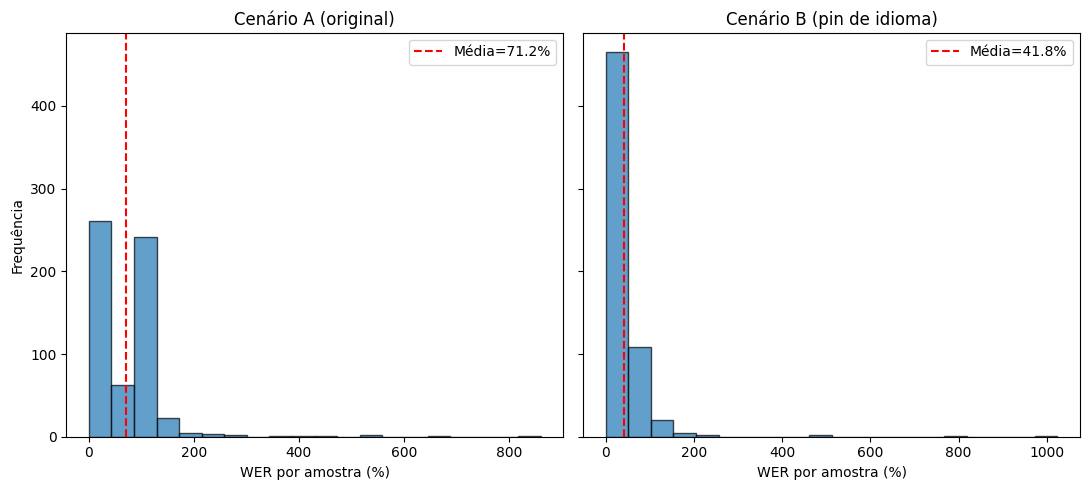

/tmp/ipykernel_2167/2466137559.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([wer_a, wer_b], labels=["A (original)", "B (pin de idioma)"], showmeans=True)


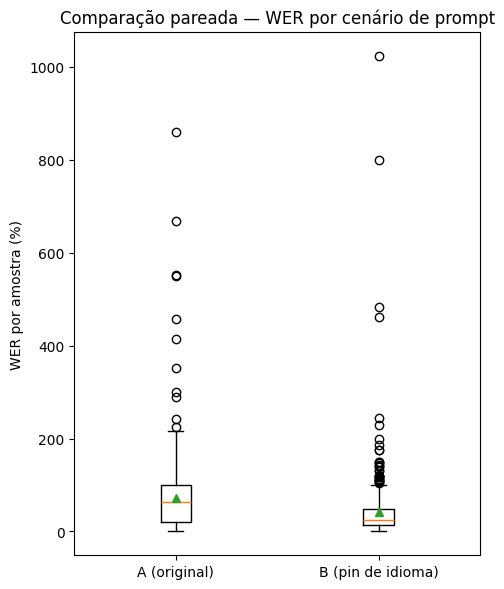

In [26]:
plots_dir = Path(PROJECT_DIR) / "results" / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)
for ax, scenario, title in zip(axes, ["A_original", "B_pt_pinned"], ["Cenário A (original)", "Cenário B (pin de idioma)"]):
    r = results_by_scenario[scenario]
    ax.hist(r["wer_pct"], bins=20, edgecolor="black", alpha=0.7)
    ax.axvline(r["mean"], color="red", linestyle="--", label=f"Média={r['mean']:.1f}%")
    ax.set_title(title)
    ax.set_xlabel("WER por amostra (%)")
    ax.legend()
axes[0].set_ylabel("Frequência")
fig.tight_layout()
fig.savefig(plots_dir / "wer_histogram_comparacao_prompts.png", dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(5, 6))
ax.boxplot([wer_a, wer_b], labels=["A (original)", "B (pin de idioma)"], showmeans=True)
ax.set_ylabel("WER por amostra (%)")
ax.set_title("Comparação pareada — WER por cenário de prompt")
fig.tight_layout()
fig.savefig(plots_dir / "wer_boxplot_comparacao_prompts.png", dpi=150)
plt.show()


## 13. Salvar resumo final

In [28]:
summary = {
    "n_samples": n,
    "quantized": bool(df["quantized"].iloc[0]) if "quantized" in df.columns and n > 0 else None,
    "scenarios": {
        scenario: {
            "mean_wer_pct": r["mean"], "std_wer_pct": r["std"],
            "bootstrap_ci_95": [float(r["ci"][0]), float(r["ci"][1])],
            "shapiro_wilk_p": float(r["shapiro_p"]),
        }
        for scenario, r in results_by_scenario.items()
    },
    "paired_test_A_vs_B": {
        "wilcoxon_stat": float(stat_ab), "p_value": float(p_ab), "cohens_d": float(d_ab),
        "mean_diff_pct_points": float(diffs_ab.mean()),
    },
}

summary_path = Path(PROJECT_DIR) / "results" / "summary_v2.json"
with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

df.to_csv(Path(PROJECT_DIR) / "results" / "per_sample_results_v2.csv", index=False)
print(f"Resumo salvo em: {summary_path}")


Resumo salvo em: /content/drive/MyDrive/eureka-audio-pt-replication/results/summary_v2.json


## 14. Estatísticas robustas complementares: mediana, IQR e distribuição por faixas

In [ ]:
import json
import pandas as pd
import numpy as np
from pathlib import Path

predictions_path = Path(PROJECT_DIR) / "results" / "predictions_v2.jsonl"
records = []
with open(predictions_path, "r", encoding="utf-8") as f:
    for line in f:
        records.append(json.loads(line))
df_check = pd.DataFrame(records)
n_check = len(df_check)

bins = [0, 10, 30, 100, 150, 100000]
bin_labels = ["0-10%", "10-30%", "30-100%", "100-150%", ">150%"]

robust_stats = {}
for scenario, col in [("A_original", "wer_A_original"), ("B_pt_pinned", "wer_B_pt_pinned")]:
    wer_pct = df_check[col].values * 100

    median_ = np.median(wer_pct)
    q1, q3 = np.percentile(wer_pct, [25, 75])
    iqr = q3 - q1

    rng = np.random.default_rng(SEED)
    boot_medians = np.array([
        np.median(rng.choice(wer_pct, size=n_check, replace=True)) for _ in range(N_BOOTSTRAP)
    ])
    ci_low, ci_high = np.percentile(boot_medians, [2.5, 97.5])

    counts, _ = np.histogram(wer_pct, bins=bins)
    dist_pct = {label: float(c / n_check * 100) for label, c in zip(bin_labels, counts)}

    robust_stats[scenario] = {
        "median_wer_pct": float(median_),
        "iqr_wer_pct": [float(q1), float(q3)],
        "median_bootstrap_ci_95": [float(ci_low), float(ci_high)],
        "distribution_by_range_pct": dist_pct,
    }

    print(f"\n=== Cenário {scenario} ===")
    print(f"Mediana: {median_:.2f}%  IQR: [{q1:.2f}%, {q3:.2f}%]")
    print(f"IC 95% da mediana (bootstrap): [{ci_low:.2f}%, {ci_high:.2f}%]")
    print("Distribuição por faixa de WER:")
    for label, pct in dist_pct.items():
        print(f"  {label:10s}: {pct:5.1f}%")

# Salva junto do resumo já existente
summary_path = Path(PROJECT_DIR) / "results" / "summary_v2.json"
with open(summary_path, "r", encoding="utf-8") as f:
    summary = json.load(f)

for scenario in robust_stats:
    summary["scenarios"][scenario].update(robust_stats[scenario])

with open(summary_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

print(f"\nEstatísticas robustas adicionadas a: {summary_path}")